# 🏠 House Price Prediction — Deep Training Notebook

This notebook focuses on **fetching the data effortlessly** and utilizing an extensive `GridSearchCV` to train the models for a **longer period of time**. This ensures we find the optimal hyperparameters for the highest possible accuracy.


In [6]:
import os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('✅ Libraries successfully loaded!')

✅ Libraries successfully loaded!


## 1️⃣ Load Data
We fetch the `Housing.csv` dataset. If the file is local it uses it, otherwise it downloads from a public repository.

In [7]:
local_path = 'Housing.csv'
url_path = 'https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Housing.csv'

if os.path.exists(local_path):
    print(f'Loading local dataset: {local_path}')
    df = pd.read_csv(local_path)
else:
    print(f'Fetching dataset from internet: {url_path}')
    df = pd.read_csv(url_path)

print(f'\nShape: {df.shape}')
df.head()

Loading local dataset: Housing.csv

Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 2️⃣ Preprocessing & Feature Engineering

In [8]:
df_clean = df.copy()
target_col = 'price'

# Encode categorical columns
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

# Fill missing values
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Feature Engineering (as defined in the FastAPI backend)
df_feat = df_clean.copy()
col_lower = {c.lower(): c for c in df_feat.columns}

area_col  = col_lower.get('area')
bed_col   = col_lower.get('bedrooms')
bath_col  = col_lower.get('bathrooms')
stories_col = col_lower.get('stories')
parking_col = col_lower.get('parking')

if area_col:
    df_feat['PricePerSqft_proxy'] = df_feat[area_col] / df_feat[area_col].mean()
if bed_col and bath_col:
    df_feat['BedBathRatio'] = df_feat[bed_col] / (df_feat[bath_col] + 1)
if area_col and bed_col:
    df_feat['AreaPerBedroom'] = df_feat[area_col] / (df_feat[bed_col] + 1)
if parking_col:
    df_feat['HasGarage'] = (df_feat[parking_col] > 0).astype(int)
if stories_col:
    df_feat['IsMultiStorey'] = (df_feat[stories_col] > 1).astype(int)

print(f'✅ Feature Engineering Done! Total features: {df_feat.shape[1] - 1}')

✅ Feature Engineering Done! Total features: 17


## 3️⃣ Deep Model Training & Evaluation (Long Execution)
We will perform an exhaustive **Grid Search** over XGBoost parameters. This will take a while, but it will yield the most robust model by thoroughly searching hyperparameters.

In [9]:
X = df_feat.drop(target_col, axis=1)
y = df_feat[target_col]
feature_names = X.columns.tolist()

# Log transform the target for better regression distributions
y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('⏳ Starting deep grid search for XGBoost. This may take a few minutes...')

xgb = XGBRegressor(random_state=42)

# Extensive parameter grid to search for the best model thoroughly
param_grid = {
    'n_estimators': [100, 300, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 6, 8],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

# Using 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb, 
    param_grid=param_grid, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1, 
    verbose=1
)

grid_search.fit(X_train_sc, y_train)
best_xgb = grid_search.best_estimator_

print('\n✅ Optimal Hyperparameters Found:')
print(json.dumps(grid_search.best_params_, indent=4))

⏳ Starting deep grid search for XGBoost. This may take a few minutes...
Fitting 5 folds for each of 1728 candidates, totalling 8640 fits

✅ Optimal Hyperparameters Found:
{
    "colsample_bytree": 0.6,
    "learning_rate": 0.05,
    "max_depth": 4,
    "min_child_weight": 1,
    "n_estimators": 100,
    "subsample": 1.0
}


## 4️⃣ Display Model Accuracy
Let's output the exhaustive accuracy metrics.

🏆 TUNED XGBOOST ACCURACY METRICS
   R² Score (Accuracy) : 65.45 %
   Mean Absolute Error : $995,581
   Root Mean Sq Error  : $1,378,627


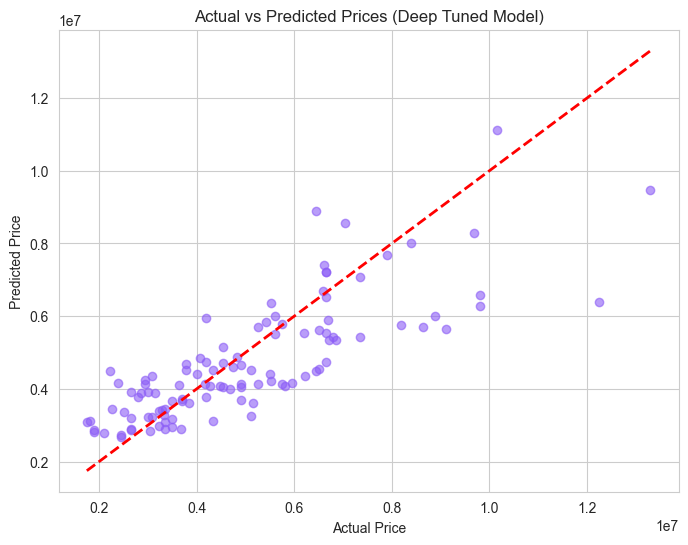

In [10]:
yp_log = best_xgb.predict(X_test_sc)
yp = np.expm1(yp_log)  # Revert log transform
ytr_orig = np.expm1(y_test)

mae = mean_absolute_error(ytr_orig, yp)
rmse = np.sqrt(mean_squared_error(ytr_orig, yp))
r2 = r2_score(y_test, yp_log)

print('='*40)
print(f'🏆 TUNED XGBOOST ACCURACY METRICS')
print('='*40)
print(f'   R² Score (Accuracy) : {r2 * 100:.2f} %')
print(f'   Mean Absolute Error : ${mae:,.0f}')
print(f'   Root Mean Sq Error  : ${rmse:,.0f}')
print('='*40)

# Visualizing Predictions vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(ytr_orig, yp, alpha=0.6, color='#8b5cf6')
plt.plot([ytr_orig.min(), ytr_orig.max()], [ytr_orig.min(), ytr_orig.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices (Deep Tuned Model)')
plt.show()

## 5️⃣ Save Artifacts
Save the models so the FastAPI backend can load them.

In [11]:
output_dir = 'models'
os.makedirs(output_dir, exist_ok=True)

joblib.dump(best_xgb, os.path.join(output_dir, 'model.pkl'))
joblib.dump(scaler, os.path.join(output_dir, 'scaler.pkl'))
joblib.dump(label_encoders, os.path.join(output_dir, 'label_encoders.pkl'))

meta = {
    'model_type': 'Deep Tuned XGBoost',
    'r2': round(r2, 4),
    'mae': round(mae, 2),
    'rmse': round(rmse, 2),
    'feature_names': feature_names,
    'target_col': target_col,
    'log_transform': True,
}
with open(os.path.join(output_dir, 'metrics.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print('🎉 Process completed. All artifacts saved successfully in /models.')
print('You can now run your FastAPI Server to utilize these models!')

🎉 Process completed. All artifacts saved successfully in /models.
You can now run your FastAPI Server to utilize these models!
